# 🛒 Milestone 1 — Tabular MLP
This notebook builds a classification model to predict review rating bands (1 to 5 stars) using product price, review count, helpful votes, and description lengths. We establish a baseline Logistic Regression model first, and then compare it with a Keras Multilayer Perceptron (MLP).

In [1]:
import sys
import os
# Add project root to path so we can import src modules
sys.path.append(os.path.abspath(os.path.join('..')))

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from src.models import build_tabular_mlp
from src.utils import evaluate_classification, plot_confusion_matrix, plot_learning_curves

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Data Splits
We load the processed parquet files created in Milestone 0.

In [2]:
data_path = "data/processed/reviews_split.parquet"
if not os.path.exists(data_path):
    data_path = "../data/processed/reviews_split.parquet"
if not os.path.exists(data_path):
    raise FileNotFoundError("Please run M0 data download/processing first.")

df = pd.read_parquet(data_path)
print(f"Loaded dataset with {len(df)} rows.")

Loaded dataset with 23927 rows.


## 2. Feature Engineering & Preprocessing
Extract input features and target. We construct features from price, review helpful votes, review text length, and first-level categories.

In [3]:
# Compute review text word count
df['review_length'] = df['text_rev'].str.split().str.len().fillna(0)

# Extract primary category from categories_str list (first item before comma)
df['primary_category'] = df['categories_str'].apply(lambda x: x.split(',')[0].strip() if x else 'Unknown')

# Input Features & Target
feature_cols = ['price_clean', 'rating_number', 'helpful_votes', 'review_length', 'primary_category']
X = df[feature_cols].copy()
y = df['rating_rev'].astype(int) - 1  # Map rating 1-5 to 0-4 classes

# Fill missing prices with median
X['price_clean'] = X['price_clean'].fillna(X['price_clean'].median())

# Filter dataset splits using splits.json frozen mapping column
train_idx = df['split'] == 'train'
val_idx = df['split'] == 'val'
test_idx = df['split'] == 'test'

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 16117, Val size: 4502, Test size: 3308


In [4]:
# Transform columns: Standardize numerical columns, one-hot encode categorical
num_features = ['price_clean', 'rating_number', 'helpful_votes', 'review_length']
cat_features = ['primary_category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print(f"Processed input shape: {X_train_proc.shape}")

Processed input shape: (16117, 5)


## 3. Baseline Model: Logistic Regression

In [5]:
print("Training Baseline Logistic Regression...")
baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline.fit(X_train_proc, y_train)

# Evaluate baseline
y_pred_base = baseline.predict(X_test_proc)
print("Baseline Results:")
evaluate_classification(y_test, y_pred_base, class_names=[f"{i+1} Stars" for i in range(5)])

Training Baseline Logistic Regression...
Baseline Results:
=== Classification Report ===
              precision    recall  f1-score   support

     1 Stars       0.11      0.04      0.06       287
     2 Stars       0.04      0.03      0.03       129
     3 Stars       0.09      0.12      0.10       244
     4 Stars       0.19      0.25      0.22       448
     5 Stars       0.71      0.71      0.71      2200

    accuracy                           0.52      3308
   macro avg       0.23      0.23      0.22      3308
weighted avg       0.52      0.52      0.52      3308

Accuracy: 0.5187
Macro F1 Score: 0.2248


{'accuracy': 0.5187424425634825, 'macro_f1': 0.22484775946823934}

## 4. Keras Tabular MLP Model

In [6]:
num_classes = 5
input_shape = (X_train_proc.shape[1],)

model = build_tabular_mlp(input_shape=input_shape, num_classes=num_classes)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,013 (11.77 KB)

 Trainable params: 2,821 (11.02 KB)

 Non-trainable params: 192 (768.00 B)

In [7]:
os.makedirs("data/checkpoints", exist_ok=True)
checkpoint_path = "data/checkpoints/tabular_mlp.keras"

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True)
]

# Class weights to balance rating classes
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print("Training Tabular MLP...")
history = model.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Training Tabular MLP...
Epoch 1/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2245 - loss: 1.8325 - val_accuracy: 0.3170 - val_loss: 1.5109
Epoch 2/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2821 - loss: 1.7016 - val_accuracy: 0.3267 - val_loss: 1.5638
Epoch 3/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2910 - loss: 1.6659 - val_accuracy: 0.2737 - val_loss: 1.5991
Epoch 4/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3044 - loss: 1.6406 - val_accuracy: 0.3754 - val_loss: 1.5473
Epoch 5/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3176 - loss: 1.6250 - val_accuracy: 0.3450 - val_loss: 1.5517
Epoch 6/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3259 - loss: 1.6110 - val_accuracy: 0.2654 - val_loss: 1.5951


## 5. Model Evaluation & Comparison

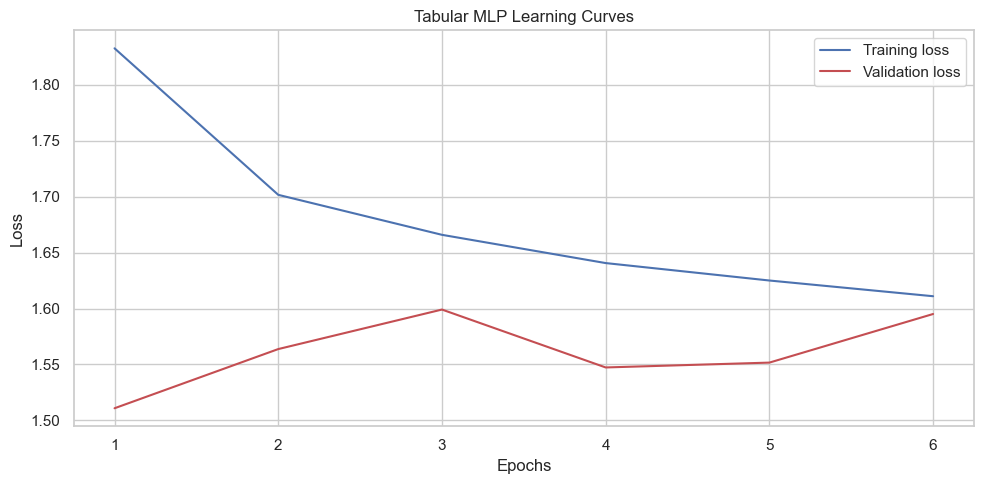

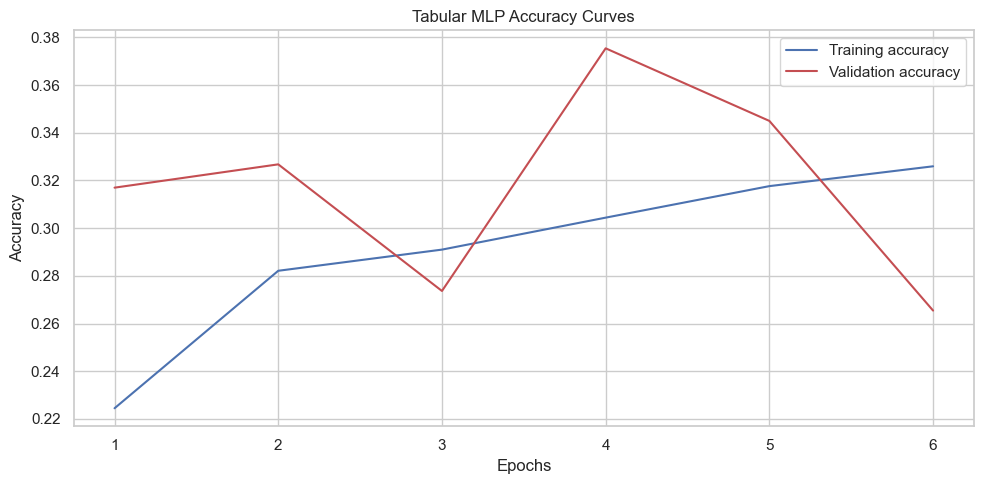

In [8]:
# Plot training loss
plot_learning_curves(history, metric='loss', title='Tabular MLP Learning Curves')
plot_learning_curves(history, metric='accuracy', title='Tabular MLP Accuracy Curves')

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Tabular MLP Results:
=== Classification Report ===
              precision    recall  f1-score   support

     1 Stars       0.09      0.72      0.17       287
     2 Stars       0.05      0.14      0.07       129
     3 Stars       0.13      0.07      0.09       244
     4 Stars       0.17      0.02      0.03       448
     5 Stars       0.76      0.20      0.31      2200

    accuracy                           0.21      3308
   macro avg       0.24      0.23      0.14      3308
weighted avg       0.55      0.21      0.24      3308

Accuracy: 0.2068
Macro F1 Score: 0.1359


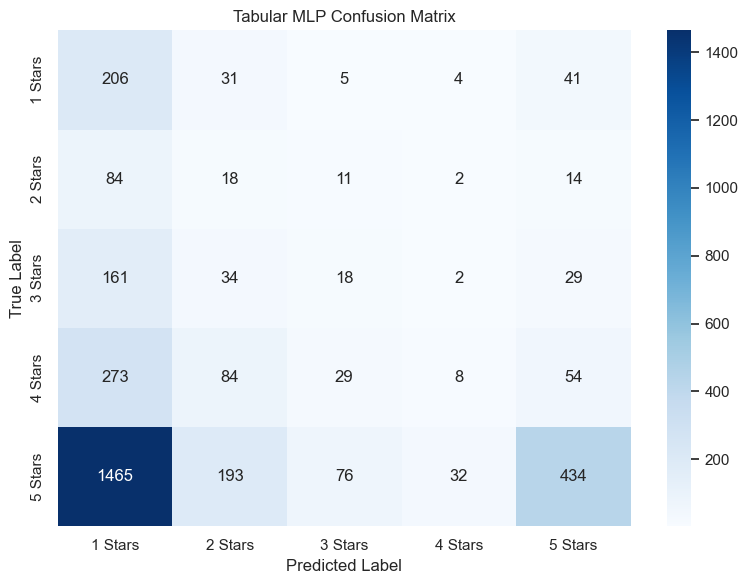

In [9]:
# Evaluate MLP
y_pred_mlp_probs = model.predict(X_test_proc)
y_pred_mlp = np.argmax(y_pred_mlp_probs, axis=1)

print("Tabular MLP Results:")
evaluate_classification(y_test, y_pred_mlp, class_names=[f"{i+1} Stars" for i in range(5)])

# Confusion Matrix comparison
plot_confusion_matrix(y_test, y_pred_mlp, class_names=[f"{i+1} Stars" for i in range(5)], title="Tabular MLP Confusion Matrix")